# ISPRA Consumo di suolo — fotografia comunale 2024 (v0)

**Domanda guida:** Quanto suolo hanno già consumato i comuni italiani, e chi sta ancora accelerando?

Perimetro operativo del `v0`:
- 7.896 comuni, anno 2024, nessun null
- Metrica principale: `stock_pct_2024` (% suolo consumato su superficie comunale)
- Dinamica recente: `incremento_ha_2023_2024` (delta ultimo anno disponibile)

**Nota:** il file ISPRA contiene anche la serie di incrementi 2006-2024, ora estratta nel dataset ma non ancora letta in questo notebook `v0`.
Il `v1` coprirà la lettura multi-periodo (issue #70).


In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'candidates').exists() and (p / 'out').exists():
            return p
    return Path.cwd().parents[2]


ROOT = _find_repo_root()
MART_PATH = ROOT / 'out' / 'data' / 'mart' / 'ispra_consumo_suolo' / '2024' / 'mart_comuni.parquet'
print('Parquet relativo:', MART_PATH.relative_to(ROOT))
print('Esiste:', MART_PATH.exists())

con = duckdb.connect()
con.execute(f"CREATE VIEW mart AS SELECT * FROM read_parquet('{MART_PATH.as_posix()}')")


Parquet relativo: out\data\mart\ispra_consumo_suolo\2024\mart_comuni.parquet
Esiste: True


## 1. Perimetro e copertura

Quanti comuni, quante regioni, quante province.
Verifica null prima di qualsiasi analisi.


In [2]:
copertura = con.execute("""
    SELECT
        COUNT(*)                                              AS n_comuni,
        COUNT(DISTINCT regione)                               AS n_regioni,
        COUNT(DISTINCT provincia)                             AS n_province,
        COUNT(*) FILTER (WHERE pro_com IS NULL)               AS null_pro_com,
        COUNT(*) FILTER (WHERE stock_ha_2024 IS NULL)         AS null_stock_ha,
        COUNT(*) FILTER (WHERE stock_pct_2024 IS NULL)        AS null_stock_pct,
        COUNT(*) FILTER (WHERE incremento_ha_2023_2024 IS NULL) AS null_incremento
    FROM mart
""").df()
print(copertura.to_string(index=False))


 n_comuni  n_regioni  n_province  null_pro_com  null_stock_ha  null_stock_pct  null_incremento
     7896         20         107             0              0               0                0


## 2. Quadro nazionale

Distribuzione di `stock_pct_2024` su tutti i comuni.
Percentili chiave come riferimento per le letture successive.


 min_pct    p25  mediana   media     p75     p95  max_pct
  0.2640 3.4340   6.5571 10.0624 12.6981 30.9294  91.8163


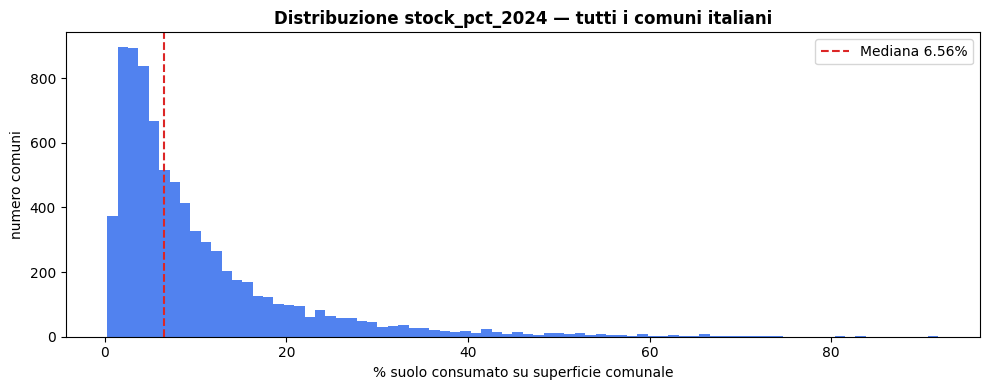

In [3]:
distrib = con.execute("""
    SELECT
        ROUND(MIN(stock_pct_2024), 4)                                                  AS min_pct,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY stock_pct_2024), 4)         AS p25,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY stock_pct_2024), 4)         AS mediana,
        ROUND(AVG(stock_pct_2024), 4)                                                  AS media,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY stock_pct_2024), 4)         AS p75,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY stock_pct_2024), 4)         AS p95,
        ROUND(MAX(stock_pct_2024), 4)                                                  AS max_pct
    FROM mart
    WHERE stock_pct_2024 > 0
""").df()
print(distrib.to_string(index=False))

# I percentili qui escludono eventuali comuni con stock_pct_2024 = 0.
n_zero = con.execute("SELECT COUNT(*) FROM mart WHERE stock_pct_2024 = 0").fetchone()[0]
print(f"Comuni con stock_pct = 0 (esclusi dall'istogramma): {n_zero}")

values = con.execute("SELECT stock_pct_2024 FROM mart WHERE stock_pct_2024 > 0").df()['stock_pct_2024']
mediana_naz = float(distrib['mediana'].iloc[0])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(values, bins=80, color='#2563EB', alpha=0.80, edgecolor='none')
ax.axvline(mediana_naz, color='#DC2626', linestyle='--', linewidth=1.5, label=f'Mediana {mediana_naz:.2f}%')
ax.set_title('Distribuzione stock_pct_2024 — tutti i comuni italiani', fontweight='bold')
ax.set_xlabel('% suolo consumato su superficie comunale')
ax.set_ylabel('numero comuni')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Lettura regionale

Pressione media per regione e comuni più compromessi.


              regione  n_comuni  stock_pct_medio  stock_pct_max  stock_ha_totale
            Lombardia      1502          16.5500        71.4800     291,198.0000
             Campania       550          15.7900        91.8200     144,055.0000
               Veneto       560          13.9600        49.6500     216,871.0000
               Puglia       257          11.4300        43.4400     158,628.0000
Friuli-Venezia Giulia       215          10.5200        46.1200      63,603.0000
       Emilia-Romagna       330          10.2900        62.5800     201,754.0000
              Sicilia       391           9.3500        54.2900     168,431.0000
              Liguria       234           8.3700        37.7900      39,524.0000
               Marche       225           8.1300        37.4800      65,141.0000
              Toscana       273           8.1000        46.1700     142,096.0000
             Piemonte      1180           7.5200        65.2100     171,136.0000
                Lazio       

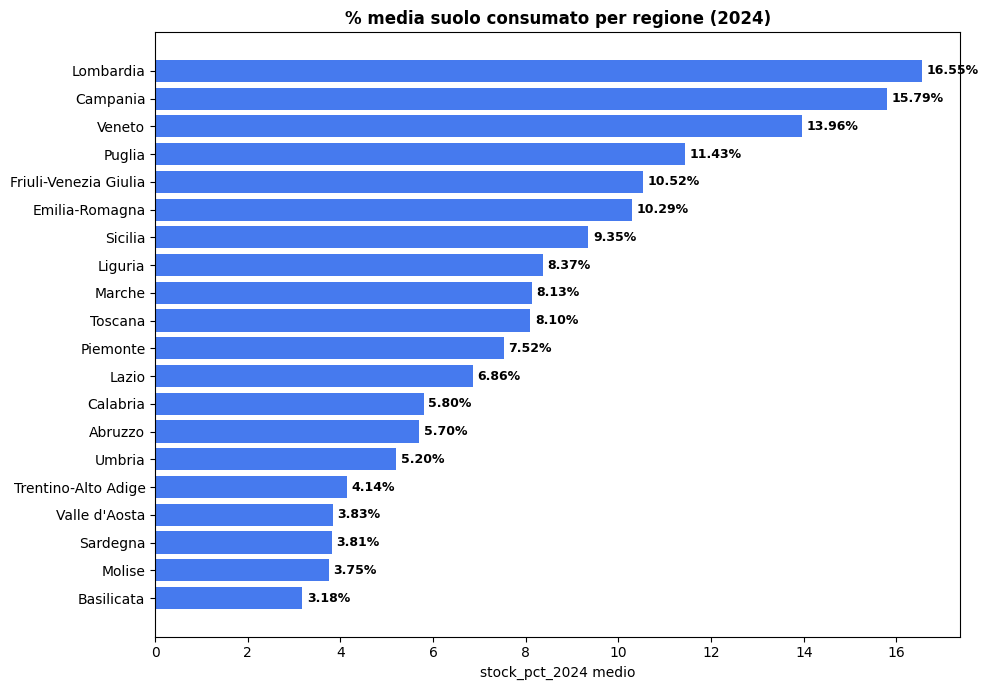

In [4]:
regioni = con.execute("""
    SELECT
        regione,
        COUNT(*)                          AS n_comuni,
        ROUND(AVG(stock_pct_2024), 2)     AS stock_pct_medio,
        ROUND(MAX(stock_pct_2024), 2)     AS stock_pct_max,
        ROUND(SUM(stock_ha_2024), 0)      AS stock_ha_totale
    FROM mart
    GROUP BY regione
    ORDER BY stock_pct_medio DESC
""").df()
print(regioni.to_string(index=False))
# stock_ha_totale non è normalizzato: non confrontare direttamente regioni di dimensioni diverse.

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(regioni['regione'], regioni['stock_pct_medio'], color='#2563EB', alpha=0.85)
for i, v in enumerate(regioni['stock_pct_medio']):
    ax.text(float(v) + 0.1, i, f'{v:.2f}%', va='center', fontsize=9, fontweight='bold')
ax.set_title('% media suolo consumato per regione (2024)', fontweight='bold')
ax.set_xlabel('stock_pct_2024 medio')
ax.invert_yaxis()
plt.tight_layout()
export_dir = ROOT / 'out' / 'notebooks' / 'ispra-consumo-suolo' / 'v0'
export_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(export_dir / 'consumo_suolo_regioni_2024.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)


## 4. Pressione recente: chi sta ancora consumando

`incremento_ha_2023_2024 > 0`: quanti comuni, dove, quanto.


Comuni con incremento > 0 nel 2023-2024: 4792 su 7896 (60.7%)
            comune        regione provincia  incremento_ha  stock_pct
         Tarquinia          Lazio   Viterbo       150.1300     4.5924
               Uta       Sardegna  Cagliari       147.5700     6.9532
Montalto Di Castro          Lazio   Viterbo       139.5900     8.1599
           Sassari       Sardegna   Sassari        90.1000     7.7952
           Ravenna Emilia-Romagna   Ravenna        75.9800    11.5689
          Tuscania          Lazio   Viterbo        65.1700     3.1341
             Trino       Piemonte  Vercelli        65.0000     7.8188
           Venezia         Veneto   Venezia        64.2100    17.1887
           Marsala        Sicilia   Trapani        61.2000    14.5616
        Carlentini        Sicilia  Siracusa        57.5100     5.4232
           Augusta        Sicilia  Siracusa        56.4400    20.4493
              Roma          Lazio      Roma        53.5900    23.6959
            Modena Emilia-Ro

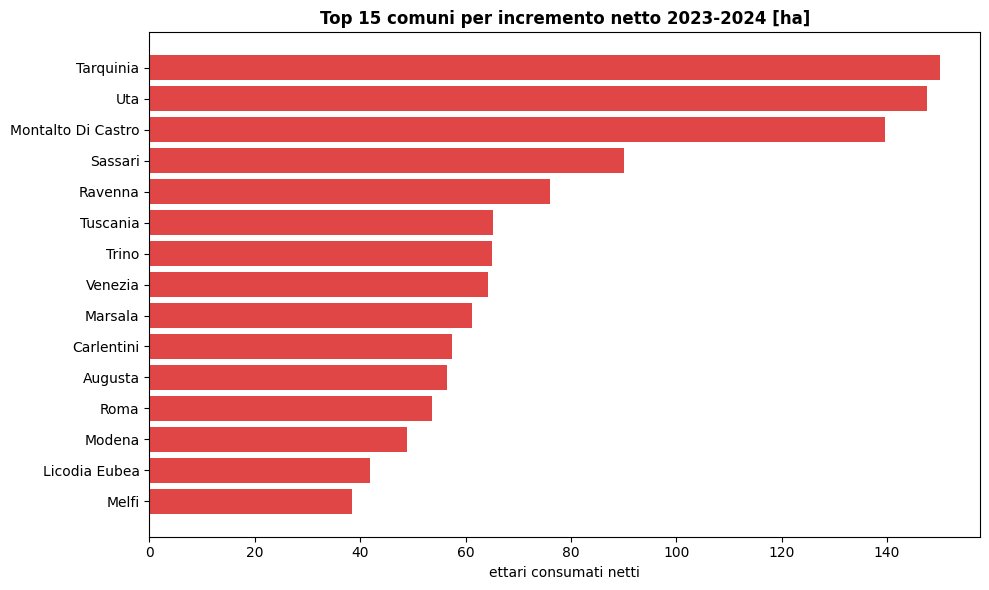

In [5]:
n_in_crescita = con.execute(
    "SELECT COUNT(*) FROM mart WHERE incremento_ha_2023_2024 > 0"
).fetchone()[0]
n_ripristino = con.execute(
    "SELECT COUNT(*) FROM mart WHERE incremento_ha_2023_2024 < 0"
).fetchone()[0]
n_totale = con.execute("SELECT COUNT(*) FROM mart").fetchone()[0]
print(f'Comuni con incremento > 0 nel 2023-2024: {n_in_crescita} su {n_totale} ({100*n_in_crescita/n_totale:.1f}%)')
print(f'Comuni con ripristino netto (incremento < 0): {n_ripristino}')

top_incremento = con.execute("""
    SELECT comune, regione, provincia,
           ROUND(incremento_ha_2023_2024, 2) AS incremento_ha,
           ROUND(stock_pct_2024, 4)          AS stock_pct
    FROM mart
    WHERE incremento_ha_2023_2024 > 0
    ORDER BY incremento_ha_2023_2024 DESC
    LIMIT 15
""").df()
print(top_incremento.to_string(index=False))
# L'incremento assoluto non è normalizzato per superficie comunale: è una lettura descrittiva, non comparativa in senso stretto.

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_incremento['comune'], top_incremento['incremento_ha'], color='#DC2626', alpha=0.85)
ax.set_title('Top 15 comuni per incremento netto 2023-2024 [ha]', fontweight='bold')
ax.set_xlabel('ettari consumati netti')
ax.invert_yaxis()
plt.tight_layout()
export_dir = ROOT / 'out' / 'notebooks' / 'ispra-consumo-suolo' / 'v0'
export_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(export_dir / 'incremento_recente_2024.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)


## 5. Outlier: i più compromessi e i più integri

Top e bottom per stock_pct e incremento.


In [6]:
top_stock_pct = con.execute("""
    SELECT comune, regione, ROUND(stock_pct_2024, 4) AS stock_pct, ROUND(stock_ha_2024, 2) AS stock_ha
    FROM mart ORDER BY stock_pct_2024 DESC LIMIT 10
""").df()

top_stock_ha = con.execute("""
    SELECT comune, regione, ROUND(stock_ha_2024, 2) AS stock_ha, ROUND(stock_pct_2024, 4) AS stock_pct
    FROM mart ORDER BY stock_ha_2024 DESC LIMIT 10
""").df()

bottom_stock_pct = con.execute("""
    SELECT comune, regione, ROUND(stock_pct_2024, 4) AS stock_pct, ROUND(stock_ha_2024, 2) AS stock_ha
    FROM mart WHERE stock_pct_2024 > 0 ORDER BY stock_pct_2024 ASC LIMIT 10
""").df()

print('--- Top 10 stock_pct_2024 (più compromessi) ---')
print(top_stock_pct.to_string(index=False))
print('')
print('--- Top 10 stock_ha_2024 (superficie assoluta) ---')
print(top_stock_ha.to_string(index=False))
print('')
print('--- Bottom 10 stock_pct_2024 > 0 (più integri) ---')
print(bottom_stock_pct.to_string(index=False))


--- Top 10 stock_pct_2024 (più compromessi) ---
            comune   regione  stock_pct  stock_ha
        Casavatore  Campania    91.8163  146.7500
            Arzano  Campania    83.3792  393.9000
  Melito Di Napoli  Campania    81.4648  305.9900
           Cardito  Campania    74.2131  236.0200
      Frattaminore  Campania    72.6328  147.4300
    Frattamaggiore  Campania    71.5436  383.0300
  Torre Annunziata  Campania    71.5150  539.1800
           Lissone Lombardia    71.4801  663.8000
           Casoria  Campania    70.8957  852.4500
Sesto San Giovanni Lombardia    69.2199  809.0700

--- Top 10 stock_ha_2024 (superficie assoluta) ---
 comune        regione    stock_ha  stock_pct
   Roma          Lazio 30,396.8200    23.6959
 Milano      Lombardia 10,667.5000    58.7213
 Torino       Piemonte  8,480.5400    65.2110
 Napoli       Campania  7,546.5000    63.6777
Ravenna Emilia-Romagna  7,533.6900    11.5689
Venezia         Veneto  7,163.9500    17.1887
Palermo        Sicilia  6,39

## 6. Nota metodologica

**Fonte:** ISPRA, rilascio 2025 — `consumo_di_suolo_estratto_dati_2025_anni_2006_2024.xlsx`, foglio `Comuni_2006_2024`.

**Anno:** 2024. Snapshot. Nessuna lettura temporale in questo notebook.

**Denominatore superficie:** fornito da ISPRA, non da ISTAT anagrafe. Può differire per comuni con variazioni territoriali recenti.

**Cosa non c'è nel v0:**
- lettura analitica della serie incrementi 2006-2024 nel notebook `v1` (vedi issue #70);
- i periodi ISPRA non sono uniformi: il file contiene intervalli misti (`2006-2012`, `2012-2015`, poi annuali fino a `2023-2024`) — non è una time series annuale pronta;
- medie regionali sensibili agli outlier comunali: utili come primo orientamento, non come misura robusta definitiva;
- join demografico (popolazione da ISTAT);
- normalizzazione per densità abitativa.

**Prossimo passo:** v1 con lettura multi-periodo degli incrementi, previa estensione di `clean.sql`.
